### Gini

Gini Index:
$$Gini(S) = 1 - \sum_{i=1}^{c} (p_i)^2$$

General Gini:
$$Gini_{split} = \frac{|S_{left}|}{|S|} Gini(S_{left}) + \frac{|S_{right}|}{|S|} Gini(S_{right})$$

$Gini = 1 - ((6/8)^2 + (2/8)^2) = 0.375$

$Gini = 1 - ((3/6)^2 + (3/6)^2) = 0.5$

$$Gini_{Wind} = \frac{8}{14} \cdot 0.375 + \frac{6}{14} \cdot 0.5 \approx \mathbf{0.428}$$

$$Gini_{Outlook} = \left( \frac{5}{14} \cdot 0.48 \right) + \left( \frac{4}{14} \cdot 0 \right) + \left( \frac{5}{14} \cdot 0.48 \right)\approx \mathbf{0.3428}$$


<font color = green >

# Decision Trees
</font>

In [25]:
import matplotlib.pyplot as plt
import numpy as np

In [26]:
%matplotlib inline

<font color = green >

## Iris dataset
</font>

In [27]:
# Don't install graphviz with the help of pip, use conda install  graphviz
# !pip install graphviz

In [28]:
# !conda install graphviz

In [29]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import graphviz
from sklearn.model_selection import train_test_split
# Note: In case of RuntimeError "Make sure the Graphviz executables are on your system's path” after installing Graphviz
# helps on mac:  brew install graphviz
import os
os.environ["PATH"] += os.pathsep + r'C:\Program Files (x86)\Graphviz2.38\bin'
os.environ["PATH"] += os.pathsep + r'C:\Program Files (x86)\Graphviz2.38\bin\dot.exe'

In [30]:
iris = load_iris()
X, y, features, labels = iris.data, iris.target,iris.feature_names ,iris.target_names

print ('X.shape= ', X.shape)
print ('y.shape= ', y.shape)
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state = 3)
print ('X_train.shape= ',X_train.shape)
print ('X_test.shape= ',X_test.shape)
print ('y_train.shape= ',y_train.shape)
print ('y_test.shape= ',y_test.shape)
print ('features:', features)
dict_names = {i:v for i,v in enumerate(labels)}
print ('target names :', dict_names)

X.shape=  (150, 4)
y.shape=  (150,)
X_train.shape=  (112, 4)
X_test.shape=  (38, 4)
y_train.shape=  (112,)
y_test.shape=  (38,)
features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
target names : {0: np.str_('setosa'), 1: np.str_('versicolor'), 2: np.str_('virginica')}


<font color = green >

## Learning the model
</font>

In [31]:
max_depth = 3
clf = DecisionTreeClassifier(
    criterion=  'entropy',
    random_state=20,
    max_depth=max_depth,
#     max_leaf_nodes=4,
).fit(X_train, y_train)
print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 98.214%
test accuracy= 97.368%


In [32]:
max_depth = 2
clf = DecisionTreeClassifier(
    criterion=  'gini',
    random_state=20,
#     max_leaf_nodes=4,
).fit(X_train, y_train)
print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 100.000%
test accuracy= 94.737%


<font color = green >

## Vizualize the decision tree  graph
</font>

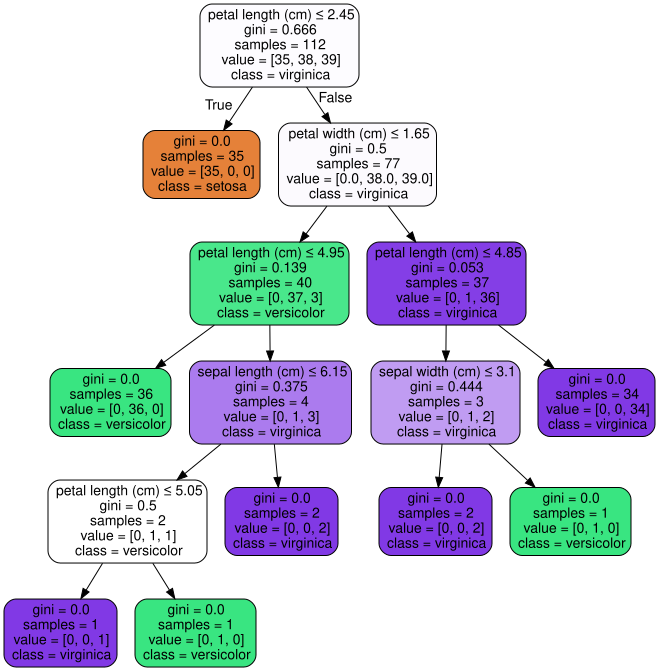

In [33]:
dot_data = tree.export_graphviz(clf, out_file=None,
                                feature_names=features,
                                class_names=labels,
                                filled=True,
                                rounded=True,
                                special_characters=True)

graph = graphviz.Source(dot_data)

display(graph)

<font color = green >

## Feature importance
</font>

In [34]:
def plot_feature_importances(clf, features):
    plt.figure(figsize=(6, 6), dpi=80)
    c_features = len(features)
    plt.barh(range(c_features), clf.feature_importances_)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature name")
    plt.yticks(np.arange(c_features), features)

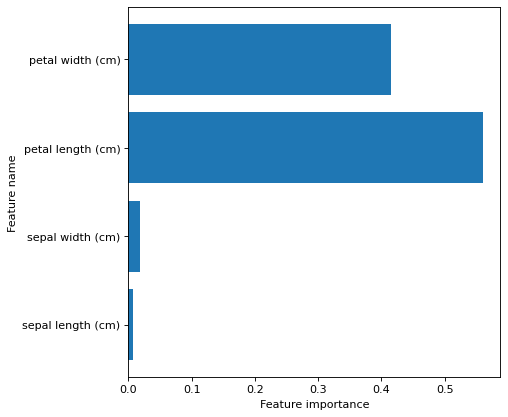

In [35]:
plot_feature_importances(clf, features)

<font color = green >

## Regressor
</font>

In [36]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression

In [37]:
X, y = make_regression(n_samples=500, n_features=5, noise=0.2, random_state=42)
features = ['Size', 'Year', 'Rooms', 'Location', 'Condition']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [38]:
reg_tree = DecisionTreeRegressor(max_depth=3, random_state=10).fit(X_train, y_train)

In [39]:
print(f"Train R² Score: {reg_tree.score(X_train, y_train):.3%}")
print(f"Test R² Score:  {reg_tree.score(X_test, y_test):.3%}")

Train R² Score: 71.579%
Test R² Score:  69.929%


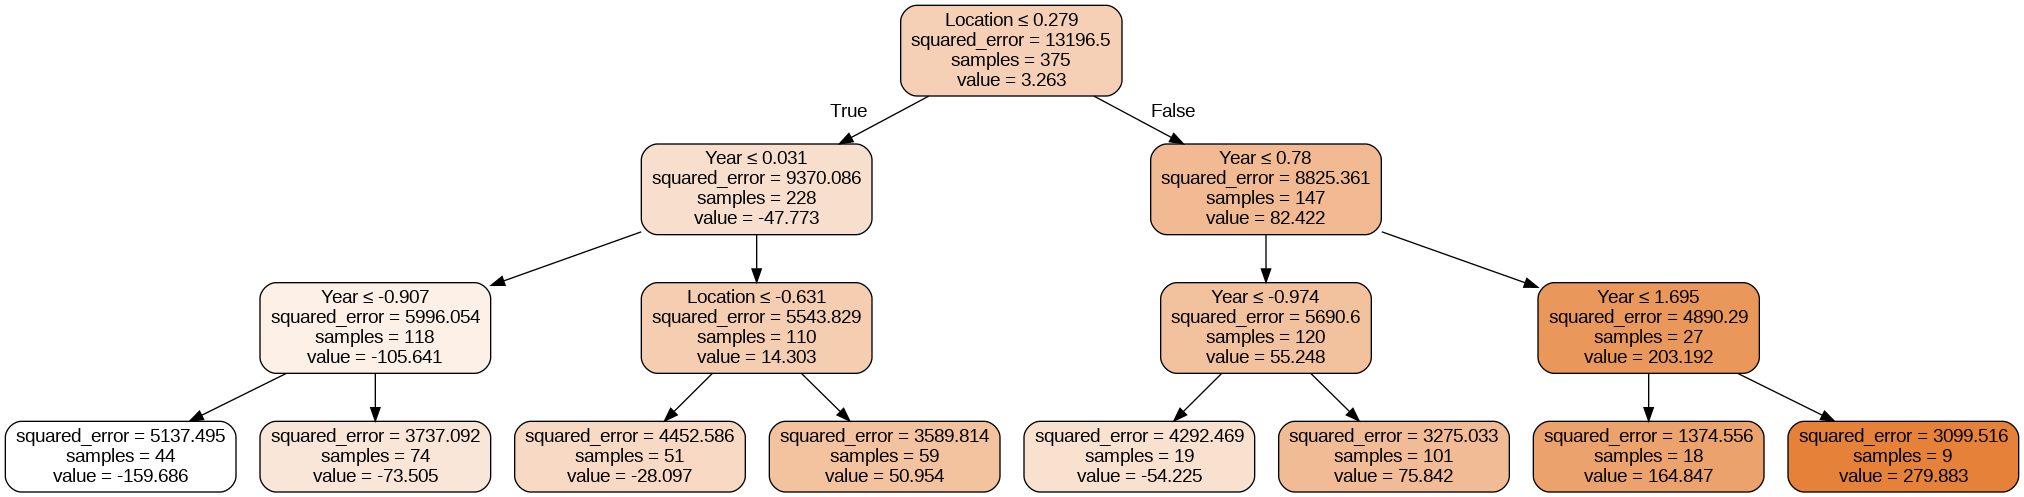

In [40]:
from IPython.display import Image

dot_data = tree.export_graphviz(reg_tree, out_file=None,
                                feature_names=features,
                                filled=True,
                                rounded=True,
                                special_characters=True)

graph = graphviz.Source(dot_data)

Image(graph.pipe(format='png'), width=1900, height=1000)

In [41]:
def plot_feature_importances(clf, features):
    plt.figure(figsize=(8, 5), dpi=80)
    n_features = len(features)
    plt.barh(range(n_features), clf.feature_importances_, color='lightgreen', edgecolor='black')
    plt.xlabel("Feature Importance (Contribution to Variance Reduction)")
    plt.ylabel("Feature Name")
    plt.yticks(np.arange(n_features), features)
    plt.title("Decision Tree Regression: Feature Importances")
    plt.show()

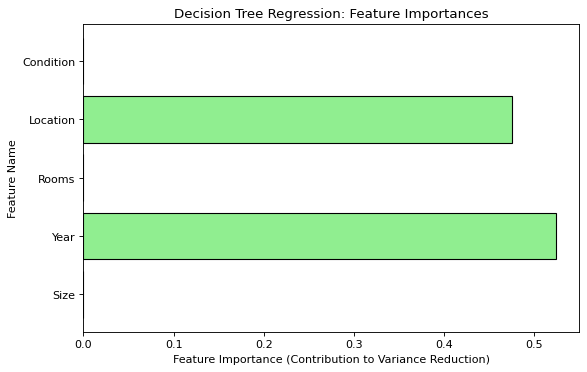

In [42]:
plot_feature_importances(reg_tree, features)

<font color = green >

## Auxiliary drawing functions
</font>

In [43]:
def plot_decision_boundary(clf, X_train, y_train, X_test=None, y_test= None, title=None, precision=0.05,plot_symbol_size = 50, ax= None,  is_extended=True, title_size= None):

    '''
    Draws the binary decision boundary for X that is nor required additional features and transformation (like polynomial)
    '''
    # Create color maps - required by pcolormesh
    from matplotlib.colors import  ListedColormap
    colors_for_points = np.array(['grey', 'orange']) # neg/pos
    colors_for_areas = np.array(['grey', 'orange']) # neg/pos  # alpha is applied later
    cmap_light = ListedColormap(colors_for_areas)


    mesh_step_size = precision #.01  # step size in the mesh
    if X_test is None or y_test is None:
        show_test= False
        X= X_train
    else:
        show_test= True
        X= np.concatenate([X_train,X_test], axis=0)
    x1_min, x1_max = X[:, 0].min() - .1, X[:, 0].max() + 0.1
    x2_min, x2_max = X[:, 1].min() - .1, X[:, 1].max() + 0.1
    # Create grids of pairs
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, mesh_step_size),
                         np.arange(x2_min, x2_max, mesh_step_size))
    # Flatten all samples
    target_samples_grid= (np.c_[xx1.ravel(), xx2.ravel()])

    print ('Call prediction for all grid values (precision of drawing = {},\n you may configure to speed up e.g. precision=0.05)'.format(precision))
    Z = clf.predict(target_samples_grid)

    # Reshape the result to original meshgrid shape
    Z = Z.reshape(xx1.shape)

    if ax:
        plt.sca(ax)

    # Plot all meshgrid prediction
    plt.pcolormesh(xx1, xx2,Z, cmap = cmap_light, alpha=0.2)

    # Plot train set
    plt.scatter(X_train[:, 0], X_train[:, 1], s=plot_symbol_size,
                c=colors_for_points[y_train.ravel()], edgecolor = 'black',alpha=0.6)
    # Plot test set
    if show_test:
        plt.scatter(X_test[:, 0], X_test[:, 1], marker='^', s=plot_symbol_size,
                c=colors_for_points[y_test.ravel()],edgecolor = 'black',alpha=0.6)
    if  is_extended:
        # Create legend
        import matplotlib.patches as mpatches # use to assign lavels for colored points
        patch0 = mpatches.Patch(color=colors_for_points[0], label='negative')
        patch1 = mpatches.Patch(color=colors_for_points[1], label='positive')
        plt.legend(handles=[patch0, patch1])

    fontdict={'fontsize': title_size} if title_size else None

    plt.title(title, fontdict)
    if is_extended:
        plt.xlabel('feature 1')
        plt.ylabel('feature 2')
    else:
        plt.tick_params(
        top =False,
        bottom= False,
        left  = False,
        labelleft = False,
        labelbottom = False
        )



def plot_data_logistic_regression(X,y,legend_loc= None, title= None):
    '''
    :param X: 2 dimensional ndarray
    :param y:  1 dimensional ndarray. Use y.ravel() if necessary
    :return:
    '''

    positive_indices = (y == 1)
    negative_indices = (y == 0)
#     import matplotlib as mpl
    colors_for_points = ['grey', 'orange'] # neg/pos

    plt.scatter(X[negative_indices][:,0], X[negative_indices][:,1], s=40, c=colors_for_points [0], edgecolor = 'black', label='negative', alpha = 0.7)
    plt.scatter(X[positive_indices][:,0], X[positive_indices][:,1], s=40, c=colors_for_points [1], edgecolor = 'black',label='positive', alpha = 0.7)
    plt.title(title)
    plt.legend(loc= legend_loc)


def plot_multi_class_logistic_regression(X,y,dict_names=None, colors= None,  title =None):
    '''
    Draw the multi class samples of 2 features
    :param X: X 2 ndarray (m,2),
    :param y: vector (m,)
    :param dict_names: dict of values of y and names
    :return: None
    '''
    if not colors:
        colors_for_points = ['green','grey', 'orange', 'brown']
    else:
         colors_for_points = colors

    y_unique = list(set(y))

    for i in range (len(y_unique)):
        ind = y == y_unique[i] # vector

        if dict_names:
            plt.scatter(X[ind,0], X[ind,1], c=colors_for_points[i], s=40, label=dict_names[y_unique[i]],edgecolor='black', alpha=.7)
        else:
            plt.scatter(X[ind, 0], X[ind, 1], s=40, c=colors_for_points [i], edgecolor = 'black', alpha = 0.7)
    if title:
        plt.title(title)

    if dict_names:
        plt.legend(frameon=True)



<font color = green >

## Synthetic dataset
</font>

In [44]:
from sklearn.datasets import make_blobs

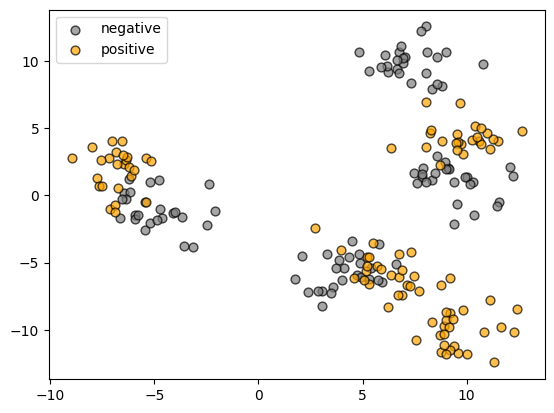

In [45]:
X_mk8, y_mk8 = make_blobs(n_samples = 200, n_features = 2, centers = 8, # centers impacts for y
                       cluster_std = 1.3, random_state = 4)
X_train = X_mk8
y_train = y_mk8 % 2 # make it binary since make_blobs  with centers = 8 creates y in [0..7]
plt.figure()
plot_data_logistic_regression(X_mk8,y_train)


Call prediction for all grid values (precision of drawing = 0.05,
 you may configure to speed up e.g. precision=0.05)
Call prediction for all grid values (precision of drawing = 0.05,
 you may configure to speed up e.g. precision=0.05)
Call prediction for all grid values (precision of drawing = 0.05,
 you may configure to speed up e.g. precision=0.05)


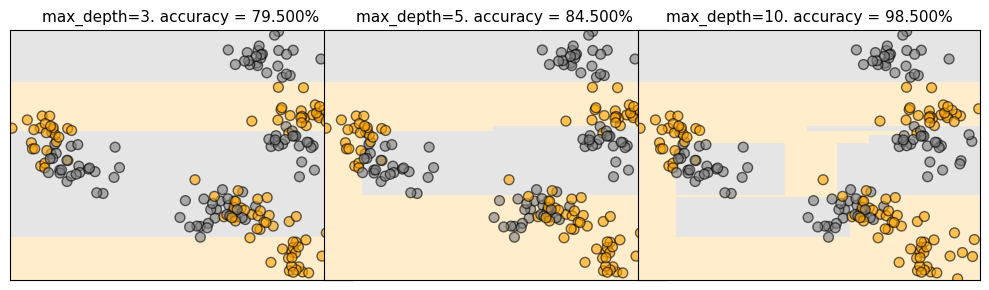

In [46]:
plt.figure(figsize= (10,3))
max_depths= [3,5,10]

for i, max_depth in enumerate(max_depths):
    ax = plt.subplot(1,len(max_depths),i+1)
    clf = DecisionTreeClassifier(
        criterion=  'entropy',
        random_state=20,
        max_depth=max_depth,
    #     max_leaf_nodes=4,
    ).fit(X_train, y_train)
    accuracy = clf.score (X_train, y_train)
#     print("train accuracy= {:.3%}".format(accuracy))
    plot_decision_boundary(
        clf,
        X_train,
        y_train,
        precision= 0.05,
        ax=ax,
        title = 'max_depth={}. accuracy = {:.3%}'.format(max_depth, accuracy),
        is_extended= False,
        title_size= 11,)

plt.tight_layout (w_pad=-2)


# max_depth=5
# clf = DecisionTreeClassifier(
#     criterion=  'entropy',
#     random_state=20,
#     max_depth=max_depth,
# #     max_leaf_nodes=4,
# ).fit(X_train, y_train)
# accuracy = clf.score (X_train, y_train)
# print("train accuracy= {:.3%}".format(accuracy))
# plt.figure()

# plot_decision_boundary(clf, X_train, y_train, precision= 0.05, title = 'max_depth={}. accuracy = {:.3%}'.format(max_depth, accuracy))

In [47]:
# graph_viz = tree.export_graphviz(clf, out_file=None,filled = True)
# graph = graphviz.Source(graph_viz)
# graph.view(cleanup =True) # cleanup (bool) – Delete the source file after rendering.

#### Should appear the followingf image in separate window

<img src = "data/decision_tree_graph2.jpg" height=500 width= 500 align="left">

<div style="clear:left;"></div>
<br><br><br><br><br><br><br><br>


<font color = green >

## Tennis dataset

</font>

In [48]:
import os
import pandas as pd
cwd= os.getcwd() # current working directory
# path = os.path.join(cwd,'data')
# fn=  os.path.join(path , 'tennis.csv')
fn=  'data/tennis.csv'
df = pd.read_csv(fn)
del df['temp']
print (df.head())

X_train = df.iloc[:, :3].values
y_train = df.iloc[:, 3].values
print ('\nX_train.shape= ',X_train.shape)
print ('y_train.shape= ',y_train.shape)

    outlook humidity   wind play
0     sunny     high  False   no
1     sunny     high   True   no
2  overcast     high  False  yes
3     rainy     high  False  yes
4     rainy   normal  False  yes

X_train.shape=  (14, 3)
y_train.shape=  (14,)


In [49]:
from sklearn.preprocessing  import LabelEncoder

In [50]:
X_train_cat = X_train.copy()
le = LabelEncoder()
for i in range(X_train.shape[1]):
    X_train_cat[:,i]= le.fit_transform(X_train[:,i])
    le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
    print ('{}: {}'.format(list(df)[i], le_dict))
y_train_cat= le.fit_transform(y_train)
le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
print ('y: ', le_dict)
print ('X_train_cat.shape= ',X_train_cat.shape)
print ('y_train_cat.shape= ',y_train_cat.shape)
X_train_cat

outlook: {'overcast': np.int64(0), 'rainy': np.int64(1), 'sunny': np.int64(2)}
humidity: {'high': np.int64(0), 'normal': np.int64(1)}
wind: {False: np.int64(0), True: np.int64(1)}
y:  {'no': np.int64(0), 'yes': np.int64(1)}
X_train_cat.shape=  (14, 3)
y_train_cat.shape=  (14,)


array([[2, 0, 0],
       [2, 0, 1],
       [0, 0, 0],
       [1, 0, 0],
       [1, 1, 0],
       [1, 1, 1],
       [0, 1, 1],
       [2, 0, 0],
       [2, 1, 0],
       [1, 1, 0],
       [2, 1, 1],
       [0, 0, 1],
       [0, 1, 0],
       [1, 0, 1]], dtype=object)

In [51]:
max_depth = None
clf = DecisionTreeClassifier(
    criterion=  'entropy',
    random_state=20,
    max_depth=max_depth,
    # max_leaf_nodes=4,
).fit(X_train_cat, y_train_cat)
features = list(df)[:3]
labels = ['No','Yes']

print("train accuracy= {:.3%}".format(clf.score (X_train_cat, y_train_cat)))

train accuracy= 100.000%


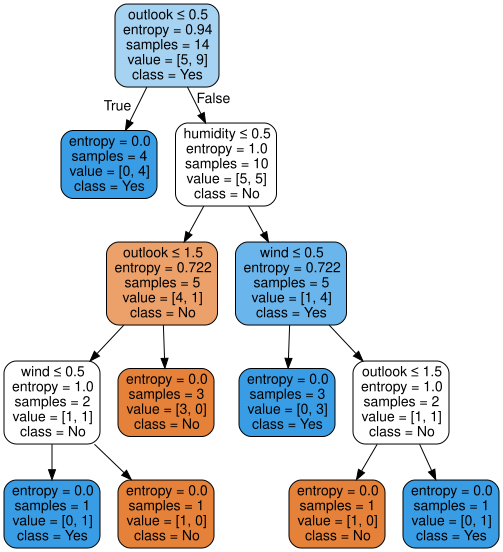

In [52]:
dot_data = tree.export_graphviz(clf, out_file=None,
                                feature_names=list(features),
                                class_names=[str(l) for l in labels],
                                filled=True,
                                rounded=True,
                                special_characters=True)

graph = graphviz.Source(dot_data)

display(graph)

<font color = green>

#  Random Forests

</font>



In [53]:
from sklearn.ensemble import RandomForestClassifier

<font color = green>

## Iris dataset

</font>



In [54]:
iris = load_iris()
X, y, features, labels = iris.data, iris.target,iris.feature_names ,iris.target_names

print ('X.shape= ', X.shape)
print ('y.shape= ', y.shape)
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state = 3)
print ('X_train.shape= ',X_train.shape)
print ('X_test.shape= ',X_test.shape)
print ('y_train.shape= ',y_train.shape)
print ('y_test.shape= ',y_test.shape)
print ('features:', features)
dict_names = {i:v for i,v in enumerate(labels)}
print ('target names :', dict_names)

X.shape=  (150, 4)
y.shape=  (150,)
X_train.shape=  (112, 4)
X_test.shape=  (38, 4)
y_train.shape=  (112,)
y_test.shape=  (38,)
features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
target names : {0: np.str_('setosa'), 1: np.str_('versicolor'), 2: np.str_('virginica')}


In [55]:
clf = RandomForestClassifier().fit (X_train, y_train)
clf.score (X_train, y_train)
n_estimators_list= [5,10,20]
max_features_list= list(np.arange(1, X_train.shape[1]+1))

for i in range (len(n_estimators_list)):
    for j in range (len(max_features_list)):
        index = len(max_features_list)*i+j
        clf = RandomForestClassifier(
            random_state=10,
            n_estimators= n_estimators_list[i],
            max_features=max_features_list[j],
        ).fit(X_train, y_train)
        accuracy_train = clf.score (X_train, y_train)
        accuracy_test = clf.score (X_test, y_test)
        print ('n_estimators= {}, max_features = {}, accuracy_train = {:.3%}, accuracy_test = {:.3%}'.format (
            n_estimators_list[i],max_features_list[j], accuracy_train, accuracy_test))

n_estimators= 5, max_features = 1, accuracy_train = 98.214%, accuracy_test = 94.737%
n_estimators= 5, max_features = 2, accuracy_train = 98.214%, accuracy_test = 94.737%
n_estimators= 5, max_features = 3, accuracy_train = 98.214%, accuracy_test = 94.737%
n_estimators= 5, max_features = 4, accuracy_train = 98.214%, accuracy_test = 94.737%
n_estimators= 10, max_features = 1, accuracy_train = 100.000%, accuracy_test = 94.737%
n_estimators= 10, max_features = 2, accuracy_train = 100.000%, accuracy_test = 97.368%
n_estimators= 10, max_features = 3, accuracy_train = 100.000%, accuracy_test = 94.737%
n_estimators= 10, max_features = 4, accuracy_train = 100.000%, accuracy_test = 94.737%
n_estimators= 20, max_features = 1, accuracy_train = 100.000%, accuracy_test = 94.737%
n_estimators= 20, max_features = 2, accuracy_train = 100.000%, accuracy_test = 97.368%
n_estimators= 20, max_features = 3, accuracy_train = 100.000%, accuracy_test = 97.368%
n_estimators= 20, max_features = 4, accuracy_train 

In [56]:
print('--- RANDOM FOREST RESULTS (ENSEMBLE) ---')
max_depth = 3
clf_rf = RandomForestClassifier(
    criterion='entropy',
    random_state=20,
    max_depth=max_depth
).fit(X_train, y_train)
print("Train accuracy (RF) = {:.3%}".format(clf_rf.score(X_train, y_train)))
print("Test accuracy (RF) = {:.3%}".format(clf_rf.score(X_test, y_test)))

print('\n--- DECISION TREE RESULTS (SINGLE TREE) ---')
clf_dt = DecisionTreeClassifier(
    criterion='entropy',
    random_state=20,
    max_depth=max_depth
).fit(X_train, y_train)
print("Train accuracy (DT) = {:.3%}".format(clf_dt.score(X_train, y_train)))
print("Test accuracy (DT) = {:.3%}".format(clf_dt.score(X_test, y_test)))

--- RANDOM FOREST RESULTS (ENSEMBLE) ---
Train accuracy (RF) = 97.321%
Test accuracy (RF) = 97.368%

--- DECISION TREE RESULTS (SINGLE TREE) ---
Train accuracy (DT) = 98.214%
Test accuracy (DT) = 97.368%


In [57]:
# Conclusion: this dataset is not good to demonstrate the power of random forest

<font color = green>

## Mushrooms dataset

</font>



In [58]:
import os
import pandas as pd
cwd= os.getcwd() # current working directory
# path = os.path.join(cwd,'data')
# fn=  os.path.join(path , 'mushrooms.csv')
fn= 'data/mushrooms.csv'
# https://www.kaggle.com/ymotonskillupai/mushroomscsv
df = pd.read_csv(fn)

print (list(df))
X = df.iloc[:, 1:].values
y = df.iloc[:, 1].values
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)
print ('\nX_train.shape= ',X_train.shape)
print ('y_train.shape= ',y_train.shape)
df.head()

['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']

X_train.shape=  (6093, 22)
y_train.shape=  (6093,)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [59]:
X_train_cat = X_train.copy()
X_test_cat = X_test.copy()
le = LabelEncoder()
for i in range(X_train.shape[1]):
    X_train_cat[:,i]= le.fit_transform(X_train[:,i])
    le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
    print (X_test[:,i])
    X_test_cat[:,i] = le.transform(X_test[:,i])
y_train_cat= le.fit_transform(y_train)
le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
print ('y: ', le_dict)
y_test_cat= le.transform(y_test)
print ('X_train_cat.shape= ',X_train_cat.shape)
print ('y_train_cat.shape= ',y_train_cat.shape)
X_train_cat

['x' 'f' 'x' ... 'x' 'x' 'k']
['y' 'y' 'y' ... 'y' 's' 's']
['n' 'g' 'y' ... 'e' 'y' 'n']
['t' 't' 't' ... 'f' 't' 'f']
['p' 'n' 'a' ... 's' 'l' 'n']
['f' 'f' 'f' ... 'f' 'f' 'a']
['c' 'c' 'c' ... 'c' 'c' 'c']
['n' 'b' 'b' ... 'n' 'b' 'b']
['p' 'p' 'k' ... 'b' 'k' 'y']
['e' 't' 'e' ... 't' 'e' 'e']
['e' 'b' 'c' ... '?' 'c' '?']
['s' 's' 's' ... 's' 's' 's']
['s' 's' 's' ... 'k' 's' 's']
['w' 'g' 'w' ... 'p' 'w' 'o']
['w' 'g' 'w' ... 'p' 'w' 'o']
['p' 'p' 'p' ... 'p' 'p' 'p']
['w' 'w' 'w' ... 'w' 'w' 'n']
['o' 'o' 'o' ... 'o' 'o' 'o']
['p' 'p' 'p' ... 'e' 'p' 'p']
['k' 'k' 'n' ... 'w' 'k' 'b']
['s' 'y' 'n' ... 'v' 's' 'c']
['u' 'd' 'm' ... 'd' 'g' 'l']
y:  {'b': np.int64(0), 'c': np.int64(1), 'f': np.int64(2), 'k': np.int64(3), 's': np.int64(4), 'x': np.int64(5)}
X_train_cat.shape=  (6093, 22)
y_train_cat.shape=  (6093,)


array([[2, 3, 9, ..., 1, 5, 1],
       [5, 3, 4, ..., 3, 5, 1],
       [2, 2, 3, ..., 2, 0, 1],
       ...,
       [5, 2, 3, ..., 3, 3, 1],
       [2, 0, 4, ..., 3, 4, 0],
       [5, 3, 3, ..., 3, 5, 0]], dtype=object)

In [60]:
max_features_list = [20,12, 10,8,6,4,3,2,1]
for i, max_features in enumerate(max_features_list):
    clf = RandomForestClassifier(
        random_state=0,
        max_features= max_features,
    ).fit(X_train_cat, y_train_cat)
    accuracy_train = clf.score(X_train_cat, y_train_cat)
    accuracy_test = clf.score(X_test_cat, y_test_cat)
    print ('max_features = {}:\n\t accuracy_train = {:.3%}\n\t accuracy_test = {:.3%}'.format (
        max_features_list[i], accuracy_train, accuracy_test))

max_features = 20:
	 accuracy_train = 100.000%
	 accuracy_test = 100.000%
max_features = 12:
	 accuracy_train = 100.000%
	 accuracy_test = 100.000%
max_features = 10:
	 accuracy_train = 100.000%
	 accuracy_test = 100.000%
max_features = 8:
	 accuracy_train = 100.000%
	 accuracy_test = 100.000%
max_features = 6:
	 accuracy_train = 100.000%
	 accuracy_test = 100.000%
max_features = 4:
	 accuracy_train = 100.000%
	 accuracy_test = 99.951%
max_features = 3:
	 accuracy_train = 100.000%
	 accuracy_test = 99.754%
max_features = 2:
	 accuracy_train = 100.000%
	 accuracy_test = 99.606%
max_features = 1:
	 accuracy_train = 100.000%
	 accuracy_test = 99.360%


In [61]:
print('--- RANDOM FOREST RESULTS (ENSEMBLE) ---')
max_depth = 3
clf_rf = RandomForestClassifier(
    criterion='entropy',
    random_state=20,
    max_depth=max_depth,
).fit(X_train_cat, y_train_cat)
print("Train accuracy (RF) = {:.3%}".format(clf_rf.score(X_train_cat, y_train_cat)))
print("Test accuracy (RF) = {:.3%}".format(clf_rf.score(X_test_cat, y_test_cat)))

print('\n--- DECISION TREE RESULTS (SINGLE TREE) ---')
clf_dt = DecisionTreeClassifier(
    criterion='entropy',
    random_state=20,
    max_depth=max_depth
).fit(X_train_cat, y_train_cat)
print("Train accuracy (DT) = {:.3%}".format(clf_dt.score(X_train_cat, y_train_cat)))
print("Test accuracy (DT) = {:.3%}".format(clf_dt.score(X_test_cat, y_test_cat)))

--- RANDOM FOREST RESULTS (ENSEMBLE) ---
Train accuracy (RF) = 94.371%
Test accuracy (RF) = 93.550%

--- DECISION TREE RESULTS (SINGLE TREE) ---
Train accuracy (DT) = 99.951%
Test accuracy (DT) = 99.951%


In [62]:
# Conclusion: this dataset is also  not good to demonstrate the power of random forest :)

<font color = green >

# Gradient boosting decision tree
</font>

In [63]:
from sklearn.ensemble import GradientBoostingClassifier

<font color = green>

## Fruits dataset 2D

</font>



In [64]:
import os
cwd= os.getcwd()
path = os.path.join(cwd,'data')
fn=  os.path.join(path , 'fruit_data_with_colors.txt')
df_fruits = pd.read_table(fn)
df_fruits.head(10)


,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.4,7.3,0.55
1,1,apple,granny_smith,180,8.0,6.8,0.59
2,1,apple,granny_smith,176,7.4,7.2,0.60
3,2,mandarin,mandarin,86,6.2,4.7,0.80
4,2,mandarin,mandarin,84,6.0,4.6,0.79
5,2,mandarin,mandarin,80,5.8,4.3,0.77
6,2,mandarin,mandarin,80,5.9,4.3,0.81
7,2,mandarin,mandarin,76,5.8,4.0,0.81
8,1,apple,braeburn,178,7.1,7.8,0.92
9,1,apple,braeburn,172,7.4,7.0,0.89


In [65]:
def plot_decision_boundary_universal(clf, X_train, y_train, X_test=None, y_test= None, title=None, precision=0.1,plot_symbol_size = 50, ax= None,  is_extended=True, labels= None, features =None):
    '''
    expected to be universal for binary and multiclass classification but not tested for binary
    '''
    # Create color maps - required by pcolormesh
    from matplotlib.colors import  ListedColormap
    colors_for_areas= colors_for_points =  np.array(['green','grey', 'orange', 'brown'])
    cmap_light = ListedColormap(colors_for_areas)

    mesh_step_size = precision #.01  # step size in the mesh
    if X_test is None or y_test is None:
        show_test= False
        X= X_train
    else:
        show_test= True
        X= np.concatenate([X_train,X_test], axis=0)
    x1_min, x1_max = X[:, 0].min() - .1, X[:, 0].max() + 0.1
    x2_min, x2_max = X[:, 1].min() - .1, X[:, 1].max() + 0.1
    # Create grids of pairs
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, mesh_step_size),
                         np.arange(x2_min, x2_max, mesh_step_size))
    # Flatten all samples
    target_samples_grid= (np.c_[xx1.ravel(), xx2.ravel()])
    if precision<0.05:
        print ('Calling to predict for all grid values (precision of drawing = {},\n you may configure to speed up e.g. precision=0.05)'.format(precision))
    Z = clf.predict(target_samples_grid)

    # Reshape the result to original meshgrid shape
    Z = Z.reshape(xx1.shape)

    if ax:
        plt.sca(ax)

    # Plot all meshgrid prediction
    plt.pcolormesh(xx1, xx2,Z, cmap = cmap_light, alpha=0.2)

    # Plot train set
    plt.scatter(X_train[:, 0], X_train[:, 1], s=plot_symbol_size,
                c=colors_for_points[y_train.ravel()], edgecolor = 'black',alpha=0.6)
    # Plot test set
    if show_test:
        plt.scatter(X_test[:, 0], X_test[:, 1], marker='^', s=plot_symbol_size,
                c=colors_for_points[y_test.ravel()],edgecolor = 'black',alpha=0.6)
    if  is_extended:

        # Create legend
        if labels is None:
            labels= ['negative','positive'] # assume this is for binary or for muticlass with labels
        import matplotlib.patches as mpatches # use to assign lavels for colored points
        patches= [mpatches.Patch(color=colors_for_points[i], label=labels[i]) for i in range (len(labels))]
        plt.legend(handles=patches)
        if features is None:
            plt.xlabel('feature 1')
            plt.ylabel('feature 2')
        else:
            plt.xlabel(features[0])
            plt.ylabel(features[1])

    else:
        plt.tick_params(
        top =False,
        bottom= False,
        left  = False,
        labelleft = False,
        labelbottom = False
        )
    plt.title(title)


X_train.shape=  (44, 2)
X_test.shape=  (15, 2)
y_train.shape=  (44,)
y_test.shape=  (15,)
target names : {np.int64(0): 'apple', np.int64(1): 'mandarin', np.int64(2): 'orange', np.int64(3): 'lemon'}


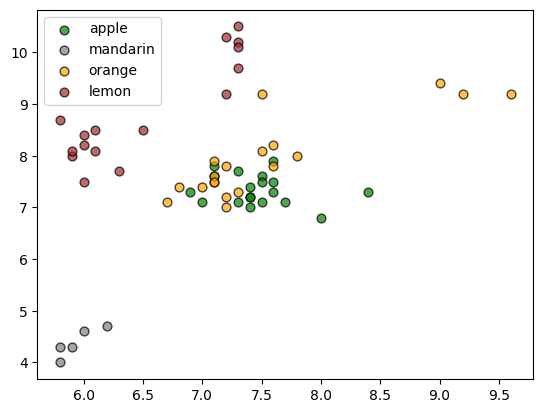

In [66]:
features = ['width', 'height']
X = df_fruits[features].values
y = df_fruits['fruit_label'].values -1  # shift due to labels of fruits are from 1

df_fruits.head(20)
# labels =  df_fruits['fruit_name'].unique()
fruits_dict = dict(zip(np.unique(y), df_fruits['fruit_name'].unique()))

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state = 3)
print ('X_train.shape= ',X_train.shape)
print ('X_test.shape= ',X_test.shape)
print ('y_train.shape= ',y_train.shape)
print ('y_test.shape= ',y_test.shape)

print ('target names :', fruits_dict)

plt.figure()
plot_multi_class_logistic_regression (X,y,dict_names=fruits_dict)


train accuracy= 95.455%
test accuracy= 80.000%


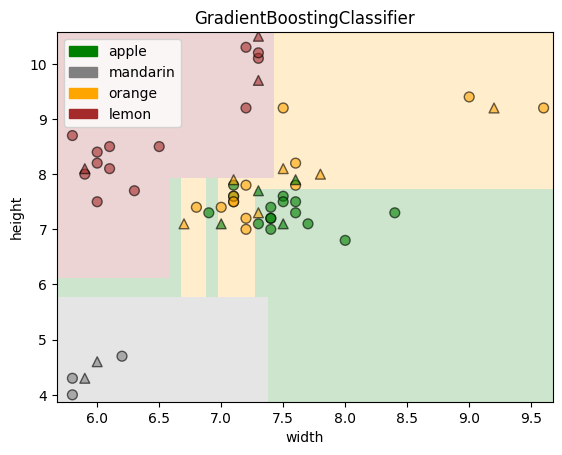

In [67]:
plt.figure ()
labels =list(fruits_dict.values())

clf = GradientBoostingClassifier(learning_rate=0.01,max_depth=3).fit(X_train, y_train)
print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))
plot_decision_boundary_universal(clf, X_train, y_train, X_test, y_test, title='GradientBoostingClassifier', precision=0.05, labels= labels, features = features)


---

<font color = green>

##  XGBoost
</font>



In [68]:
!pip install XGBoost

In [69]:
from xgboost import XGBClassifier

clf_xgboost = XGBClassifier(use_label_encoder=False, eval_metric= 'logloss')
clf_xgboost.fit(X_train, y_train)
print('\nAccuracy of Logistic regression classifier on training set: {:.2f}'
     .format(clf_xgboost.score(X_train, y_train)))
print('Accuracy of Logistic regression classifier on test set: {:.2f}'
     .format(clf_xgboost.score(X_test, y_test)))




Accuracy of Logistic regression classifier on training set: 0.98
Accuracy of Logistic regression classifier on test set: 0.60


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:40:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [70]:
help(XGBClassifier)

Help on class XGBClassifier in module xgboost.sklearn:

class XGBClassifier(sklearn.base.ClassifierMixin, XGBModel)
 |  XGBClassifier(*, objective: Union[str, xgboost.sklearn._SklObjWProto, Callable[[Any, Any], Tuple[numpy.ndarray, numpy.ndarray]], NoneType] = 'binary:logistic', **kwargs: Any) -> None
 |
 |  Implementation of the scikit-learn API for XGBoost classification.
 |  See :doc:`/python/sklearn_estimator` for more information.
 |
 |  Parameters
 |  ----------
 |
 |      n_estimators : Optional[int]
 |          Number of boosting rounds.
 |
 |      max_depth :  typing.Optional[int]
 |
 |          Maximum tree depth for base learners.
 |
 |      max_leaves : typing.Optional[int]
 |
 |          Maximum number of leaves; 0 indicates no limit.
 |
 |      max_bin : typing.Optional[int]
 |
 |          If using histogram-based algorithm, maximum number of bins per feature
 |
 |      grow_policy : typing.Optional[str]
 |
 |          Tree growing policy.
 |
 |          - depthwise: Favo

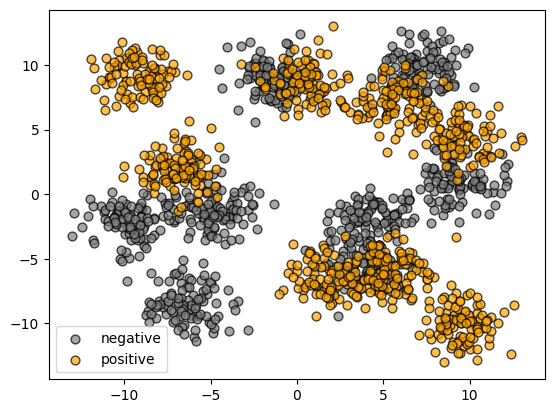

In [71]:
X_mk8, y_mk8 = make_blobs(n_samples = 2000, n_features = 2, centers = 16, # centers impacts for y
                       cluster_std = 1.3, random_state = 4)
X = X_mk8
y = y_mk8 % 2 # make it binary since make_blobs  with centers = 8 creates y in [0..7]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)
plt.figure()
plot_data_logistic_regression(X_train,y_train)

In [72]:
print(X_train.shape)
y_train.shape

(1500, 2)


(1500,)

In [73]:
X_train

array([[ -7.11271763,  -2.18572036],
       [  9.04587707, -11.46625813],
       [ -4.37859762,   1.69193429],
       ...,
       [  5.26290094,  -5.6390031 ],
       [  1.0183784 ,  -6.95986805],
       [ -6.21752906,  -0.20391296]])

In [74]:
common_max_depth = 3
seed = 10

print('='*30)
print('DECISION TREE')
clf_dt = DecisionTreeClassifier(
    criterion='entropy',
    random_state=seed,
    max_depth=common_max_depth
).fit(X_train, y_train)
print("Train accuracy = {:.3%}".format(clf_dt.score(X_train, y_train)))
print("Test accuracy  = {:.3%}".format(clf_dt.score(X_test, y_test)))

print('\n' + '='*30)
print('RANDOM FOREST')
clf_rf = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    max_depth=common_max_depth,
    random_state=seed
).fit(X_train, y_train)
print("Train accuracy = {:.3%}".format(clf_rf.score(X_train, y_train)))
print("Test accuracy  = {:.3%}".format(clf_rf.score(X_test, y_test)))

print('\n' + '='*30)
print('GRADIENT BOOSTING')
clf_gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=common_max_depth,
    random_state=seed
).fit(X_train, y_train)
print("Train accuracy = {:.3%}".format(clf_gb.score(X_train, y_train)))
print("Test accuracy  = {:.3%}".format(clf_gb.score(X_test, y_test)))

print('\n' + '='*30)
print('XGBOOST')
clf_xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    n_estimators=100,
    max_depth=common_max_depth,
    random_state=seed
).fit(X_train, y_train)
print("Train accuracy = {:.3%}".format(clf_xgb.score(X_train, y_train)))
print("Test accuracy  = {:.3%}".format(clf_xgb.score(X_test, y_test)))

DECISION TREE
Train accuracy = 82.267%
Test accuracy  = 78.400%

RANDOM FOREST
Train accuracy = 85.800%
Test accuracy  = 80.200%

GRADIENT BOOSTING
Train accuracy = 91.667%
Test accuracy  = 83.000%

XGBOOST


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:40:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Train accuracy = 93.000%
Test accuracy  = 83.400%


<font color = green >
    
# Home Task

</font>



<font color = green>

##  Brest cancer  dataset
</font>



In [75]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
X, y, labels, features = cancer.data, cancer.target, cancer.target_names, cancer.feature_names
print ('labels:',labels)
print ('features:', features)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)

labels: ['malignant' 'benign']
features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


<font color = green>

##  DecisionTree

</font>



In [76]:
# YOUR_CODE.  create the classifier and train it
# START_CODE
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=0, max_depth=4)
clf.fit(X_train, y_train)
# END_CODE

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))
graph_viz = tree.export_graphviz(clf, out_file=None,feature_names=features, class_names=labels, filled = True)
graph = graphviz.Source(graph_viz)
graph.view(cleanup =True) # cleanup (bool) – Delete the source file after rendering.

train accuracy= 99.296%
test accuracy= 90.210%


'Source.gv.pdf'

<font color = green>

##  RandomForest

</font>



In [77]:
# YOUR_CODE.  create the classifier and train it
# START_CODE
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100, random_state=0, max_depth=4)
clf.fit(X_train, y_train)
# END_CODE

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 99.296%
test accuracy= 96.503%


<font color = green>

##  Gradient Boosting Decision Trees (GBDT)

</font>



In [78]:
# YOUR_CODE.  create the classifier and train it
# START_CODE
from sklearn.ensemble import GradientBoostingClassifier
clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=0, max_depth=3)
clf.fit(X_train, y_train)
# END_CODE

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 100.000%
test accuracy= 96.503%


<font color = green>

##  XGBoost

</font>



In [79]:
# YOUR_CODE.  create the classifier and train it
# START_CODE
from xgboost import XGBClassifier
clf = XGBClassifier( eval_metric='logloss', random_state=0, max_depth=3)
clf.fit(X_train, y_train)
# END_CODE

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 100.000%
test accuracy= 98.601%


# Additional tasks

### 1) Binary Classification:
    Task: Train an XGBClassifier to predict whether a person's income exceeds $50,000 per year based on census data (age, education, occupation, etc.).

### 2) Regression:
    Task: Train an XGBRegressor to predict the final sale price of houses in Ames, Iowa, based on various features (area, quality, year built).

_____________________________________________________________________________________________________________________________________________________________________________________________________________________

## Assessment Criteria and Requirements

I will evaluate the entire process of working on your project—from the moment you load the dataset to the final result. Your task is to apply all the knowledge you have gained in lectures up to this point.

There is no minimum accuracy threshold: the main focus will be on the quality of implementation. However, if the model’s accuracy is too low, the assignment may not be accepted.

In [80]:
from sklearn.datasets import fetch_openml
import pandas as pd

# Classification:

In [81]:
data_class = fetch_openml(name='adult', version=2, as_frame=True)
df_income = data_class.frame
df_income

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [89]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X_clf = df_income.drop('class', axis=1).copy()
y_clf = df_income['class'].copy()

for col in X_clf.select_dtypes(['object', 'category']).columns:
    X_clf[col] = X_clf[col].astype('category')

le = LabelEncoder()
y_clf = le.fit_transform(y_clf)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

xgb_clf = XGBClassifier(enable_categorical=True, tree_method='hist', random_state=42, eval_metric='logloss')
xgb_clf.fit(X_train_c, y_train_c)

y_pred_c = xgb_clf.predict(X_test_c)
print("Adult Income Classification Results:")
print("Accuracy on Test Set: {:.2f}%".format(accuracy_score(y_test_c, y_pred_c) * 100))
print("\nClassification Report:\n", classification_report(y_test_c, y_pred_c))

Adult Income Classification Results:
Accuracy on Test Set: 87.63%

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.94      0.92      7479
           1       0.77      0.67      0.72      2290

    accuracy                           0.88      9769
   macro avg       0.84      0.81      0.82      9769
weighted avg       0.87      0.88      0.87      9769



# Regression:

In [83]:
data_reg = fetch_openml(name='house_prices', version=1, as_frame=True)
df_house = data_reg.frame
df_house

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [95]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X_reg = df_house.drop(['Id', 'SalePrice'], axis=1).copy()
y_reg = df_house['SalePrice'].copy()

for col in X_reg.select_dtypes(['object', 'category']).columns:
    X_reg[col] = X_reg[col].astype('category')

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

xgb_reg = XGBRegressor(enable_categorical=True, tree_method='hist', random_state=42)
xgb_reg.fit(X_train_r, y_train_r)

y_pred_r = xgb_reg.predict(X_test_r)

print("House Prices Regression Results:")
print("Mean Absolute Error (MAE): ${:,.2f}".format(mean_absolute_error(y_test_r, y_pred_r)))
print("R-squared (R2) Score: {:.2f}%".format(r2_score(y_test_r, y_pred_r) * 100))

House Prices Regression Results:
Mean Absolute Error (MAE): $16,871.10
R-squared (R2) Score: 91.15%


In [93]:
X_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   MSSubClass     1460 non-null   int64   
 1   MSZoning       1460 non-null   category
 2   LotFrontage    1201 non-null   float64 
 3   LotArea        1460 non-null   int64   
 4   Street         1460 non-null   category
 5   Alley          91 non-null     category
 6   LotShape       1460 non-null   category
 7   LandContour    1460 non-null   category
 8   Utilities      1460 non-null   category
 9   LotConfig      1460 non-null   category
 10  LandSlope      1460 non-null   category
 11  Neighborhood   1460 non-null   category
 12  Condition1     1460 non-null   category
 13  Condition2     1460 non-null   category
 14  BldgType       1460 non-null   category
 15  HouseStyle     1460 non-null   category
 16  OverallQual    1460 non-null   int64   
 17  OverallCond    1460 non-null   in

Text(0, 0.5, 'Predicted')

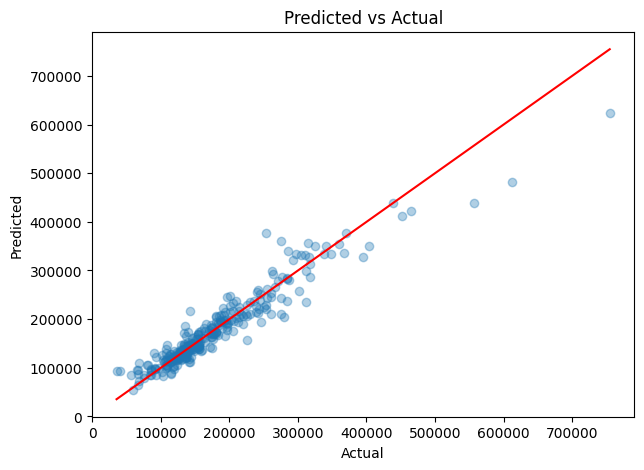

In [112]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(7, 5))

plt.scatter(y_test_r, y_pred_r, alpha=0.35)
min_val = min(y_test_r.min(), y_pred_r.min())
max_val = max(y_test_r.max(), y_pred_r.max())
plt.plot([min_val, max_val], [min_val, max_val], color = 'red')
ax.set_title("Predicted vs Actual")
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")